In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from engine import Value, Neuron, Layer, MLP

In [4]:
np.random.seed(1337)
random.seed(1337)

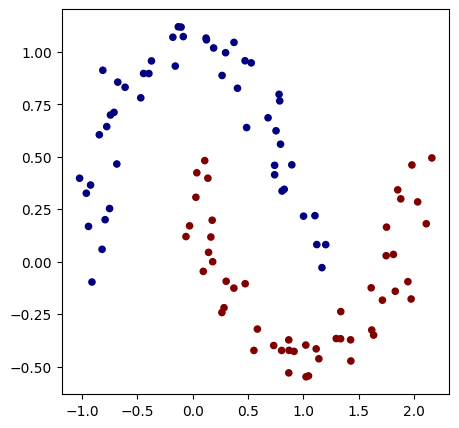

In [5]:

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [6]:
X[:10]

array([[ 1.12211461,  0.08147717],
       [-0.81882941,  0.05879006],
       [ 1.61370966, -0.1246459 ],
       [-0.92300918,  0.3652289 ],
       [ 0.14385146,  0.04438005],
       [ 0.16447247,  0.11738346],
       [ 1.33877062, -0.23800993],
       [ 0.87114861, -0.42271759],
       [ 1.83129946, -0.14104383],
       [ 0.4875712 ,  0.63909283]])

In [7]:
y[:10]

array([-1, -1,  1, -1,  1,  1,  1,  1,  1, -1])

In [8]:
# initialize a model 
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))

number of parameters 337


In [9]:
def loss(batch_size=None):

    # Load all data
    if batch_size is None:
        Xb, yb = X, y
    # build batch size
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]

    inputs = [list(map(Value, xrow)) for xrow in Xb]

    # forward model to get scores
    y_pred = [model(input) for input in inputs]

    # svm "max-margin" loss to be optimized
    losses = [(1+ -yi*scorei).relu() for yi, scorei in zip(yb, y_pred)]
    data_loss = sum(losses) * (1.0 / len(losses))

    # L2 Regularization for params to penalize big changes to params
    alpha = 1e-4
    reg_loss = alpha * sum((p for p in model.parameters()))
    total_loss = data_loss + reg_loss

    # accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, y_pred)]
    return total_loss, sum(accuracy)/len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)

Value(data=0.7738123098581592) 0.68


In [ ]:
# optimization; relu ends up in dead relu problem
for k in range(100):

    
    total_loss, acc = loss()
    
    # zero out grad
    model.zero_grad()

    # backward pass
    total_loss.backward()

    # update params based on gradients
    learning_rate = 1.0-0.9*k/100 # dyanmic learning rate
    for p in model.parameters():
        p.data = p.data - learning_rate* p.grad

    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

step 0 loss 0.7738123098581592, accuracy 68.0%
step 1 loss 0.5244178095373392, accuracy 73.0%
step 2 loss 0.39456280571070795, accuracy 83.0%
step 3 loss 0.3277432652916048, accuracy 86.0%
step 4 loss 0.28384088105479494, accuracy 88.0%
step 5 loss 0.26085273744803367, accuracy 90.0%
step 6 loss 0.24517315217240782, accuracy 90.0%
step 7 loss 0.2328459380505921, accuracy 91.0%
step 8 loss 0.22234234943880862, accuracy 91.0%
step 9 loss 0.21284806353575822, accuracy 91.0%
step 10 loss 0.20382492511021627, accuracy 91.0%
step 11 loss 0.19496321811708547, accuracy 91.0%
step 12 loss 0.18604156711058129, accuracy 93.0%
step 13 loss 0.1769406728929999, accuracy 93.0%
step 14 loss 0.16759128190882713, accuracy 94.0%
step 15 loss 0.15809297894276397, accuracy 94.0%
step 16 loss 0.14860888854053636, accuracy 94.0%
step 17 loss 0.14015105626995858, accuracy 96.0%
step 18 loss 0.13359385391579473, accuracy 96.0%
step 19 loss 0.141195045190562, accuracy 95.0%
step 20 loss 0.1320753475674032, accu

(-1.548639298268643, 1.951360701731357)

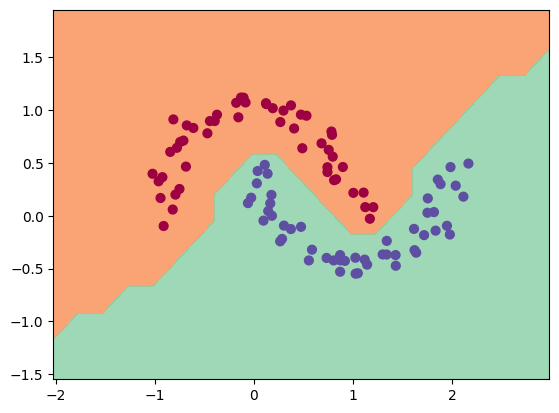

In [11]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
